<a href="https://colab.research.google.com/github/danamelissamendoza/Talleres-del-curso-IA-aplicada-a-la-economia/blob/main/Taller_Clustering_Dana_Mendoza_y_Manuela_Vasquez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/1_Taller_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Agrupando Países por su Desarrollo Económico**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Dana Melissa Mendoza Santiago
- Manuela Vásquez Osorio

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_Clustering_nombres_y_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/P5SZPPS1Ve.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

14 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

**Caso de Estudio: Consultoría para el PNUD**

**Contexto:** El Programa de las Naciones Unidas para el Desarrollo (PNUD) busca optimizar la asignación de recursos y la creación de políticas públicas. En lugar de aplicar
una única estrategia para todos, quieren entender si existen grupos de países con perfiles de desarrollo similares para crear programas de ayuda más efectivos.

**Tu Misión:** Como economista y científico de datos, tu equipo ha sido contratado para analizar un conjunto de datos con indicadores socio-económicos y de salud. Deberás aplicar técnicas de clustering para identificar estos grupos y presentar un perfil detallado de cada uno, junto con una recomendación de política.

## Ejercicio 1: Configuración inicial

1. Importa todas las librerías necesarias

In [1]:
# Importación de librerías estándar
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de modelos y métricas de Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Ejercicio 2: Carga y Exploración de Datos

1. Carga el dataset 'Country-data.csv'.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/taller clustering/Country-data.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.20,46.60,5.25,52.70,2950,2.62,63.00,3.50,2970
163,Venezuela,17.10,28.50,4.91,17.60,16500,45.90,75.40,2.47,13500
164,Vietnam,23.30,72.00,6.84,80.20,4490,12.10,73.10,1.95,1310
165,Yemen,56.30,30.00,5.18,34.40,4480,23.60,67.50,4.67,1310


2. Muestra las 5 primeras filas

In [6]:
print("Primeras filas:")
df.head()


Primeras filas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


3. Obtén información general del dataset como tipos de datos, número de filas y columnas, cantidad de valores faltantes

In [7]:
print("\nInformación del DataFrame:")
df.info()



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


4. Obtén las estadísticas descriptivas de las variables del dataset

In [8]:
print("\nEstadísticas Descriptivas:")
df.describe()


Estadísticas Descriptivas:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,"17,144.69",7.78,70.56,2.95,"12,964.16"
std,40.33,27.41,2.75,24.21,"19,278.07",10.57,8.89,1.51,"18,328.70"
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,"3,355.00",1.81,65.30,1.79,"1,330.00"
50%,19.30,35.00,6.32,43.30,"9,960.00",5.39,73.10,2.41,"4,660.00"
75%,62.10,51.35,8.60,58.75,"22,800.00",10.75,76.80,3.88,"14,050.00"
max,208.00,200.00,17.90,174.00,"125,000.00",104.00,82.80,7.49,"105,000.00"


5. ¿Hay valores nulos?

In [9]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


No hay valores nulos

6. ¿Las escalas de las variables son muy diferentes?

El conjunto de datos presenta una disparidad significativa en las escalas de medida entre sus variables, lo cual es un factor crítico en el análisis estadístico. Mientras que indicadores sociales como la tasa de fertilidad se mueven en un rango reducido de entre 1 y 7 unidades, las variables económicas como el ingreso neto o el PIB per cápita alcanzan valores que superan las 100,000 unidades. Esta diferencia de magnitudes implica que las variables financieras tienen una varianza numéricamente mucho mayor que las sociales o demográficas, a pesar de que ambas dimensiones son igualmente relevantes para caracterizar el nivel de desarrollo de un país.

7. ¿Qué implicaciones tiene esto para el análisis de clustering?


Desde la perspectiva del aprendizaje no supervisado, esta diferencia de escalas tiene implicaciones directas en el funcionamiento del algoritmo K-Means. Debido a que este modelo se basa en el cálculo de distancias euclidianas para agrupar los datos, las variables con rangos numéricos más grandes dominan el cálculo de la distancia, "opacando" a las variables de menor escala. Sin un proceso previo de estandarización o escalado, el algoritmo agruparía a los países basándose casi exclusivamente en su riqueza monetaria, ignorando matices vitales presentes en la mortalidad infantil o la esperanza de vida, lo que resultaría en clusters sesgados que no representarían la realidad multidimensional de los datos.

8. Redacta un análisis de las estadísticas descriptivas

Al observar las estadísticas descriptivas de la muestra, destaca una profunda desigualdad estructural a nivel global. El PIB per cápita (gdpp) muestra una brecha abismal: el 25% de los países de la muestra subsiste con menos de 1,330 unidades, mientras que el valor máximo asciende a 105,000. Esta asimetría se refleja también en el ingreso neto, sugiriendo una alta concentración de la riqueza. Además, la elevada desviación estándar en estas variables económicas indica que el promedio no es una medida de tendencia central confiable en este contexto, lo que justifica técnicamente la necesidad de segmentar la población en grupos o clusters.

En el ámbito social, los datos revelan situaciones de vulnerabilidad extrema en ciertos sectores. La mortalidad infantil presenta una media de 38.2 muertes por cada mil nacidos, pero con una variabilidad tal que alcanza un máximo de 208, una cifra alarmante frente al mínimo de 2.6 observado en las naciones más desarrolladas. De igual forma, aunque la esperanza de vida promedio se sitúa en los 70.5 años, existen registros donde este indicador cae hasta los 32.1 años. Estos contrastes evidencian que, bajo los promedios globales, coexisten realidades de bienestar avanzado con escenarios de privación absoluta, reforzando la importancia de un análisis detallado por perfiles socioeconómicos.

## Ejercicio 3: Preprocesamiento de Datos

1. Selecciona solo las variables numéricas para el clustering

In [10]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

df_numeric.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


2. Estandariza las variables usando StandardScaler

In [11]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

df_scaled

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
1,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
2,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
3,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
4,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04
...,...,...,...,...,...,...,...,...,...
162,-0.23,0.20,-0.57,0.24,-0.74,-0.49,-0.85,0.37,-0.55
163,-0.53,-0.46,-0.70,-1.21,-0.03,3.62,0.55,-0.32,0.03
164,-0.37,1.13,0.01,1.38,-0.66,0.41,0.29,-0.66,-0.64
165,0.45,-0.41,-0.60,-0.52,-0.66,1.50,-0.34,1.14,-0.64


## Ejercicio 4: K-Means Clustering

Usa K-Means para encontrar los clusters. Primero, debes decidir el número óptimo de clusters (k).

1. Usa el Método del Codo para encontrar el k óptimo.
Prueba un rango de k de 1 a 10. Grafica.

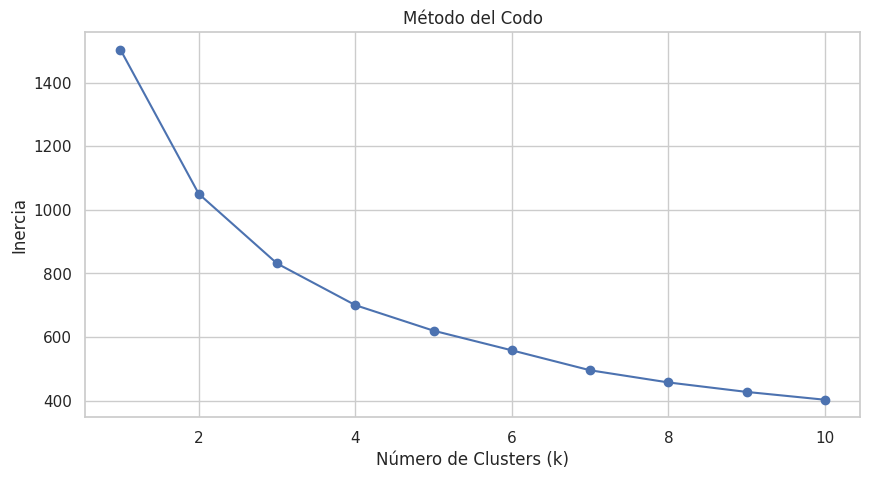

In [12]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.show()

2. ¿Dónde está el "codo"? ¿Qué número de clusters (k) parece ser el más adecuado? Justifiquen su elección.

El “codo” se observa aproximadamente en k = 3. Hasta este punto, la inercia disminuye de manera bastante pronunciada (de k=1 a k=3), lo que indica que agregar clusters mejora significativamente el modelo. Sin embargo, a partir de k ≥ 4, la reducción de la inercia se vuelve mucho más gradual.

Por lo tanto, el número de clusters más adecuado es k = 3, ya que a partir de este valor las mejoras son marginales. Esto sugiere que tres clusters logran un buen equilibrio entre simplicidad del modelo y capacidad de agrupamiento de los datos.

3. Calcula y grafica el coeficiente de silueta

Para n_clusters = 2, el coeficiente de silueta promedio es: 0.2874
Para n_clusters = 3, el coeficiente de silueta promedio es: 0.2833
Para n_clusters = 4, el coeficiente de silueta promedio es: 0.2960
Para n_clusters = 5, el coeficiente de silueta promedio es: 0.2993
Para n_clusters = 6, el coeficiente de silueta promedio es: 0.2287
Para n_clusters = 7, el coeficiente de silueta promedio es: 0.2477
Para n_clusters = 8, el coeficiente de silueta promedio es: 0.2388
Para n_clusters = 9, el coeficiente de silueta promedio es: 0.2073
Para n_clusters = 10, el coeficiente de silueta promedio es: 0.2022


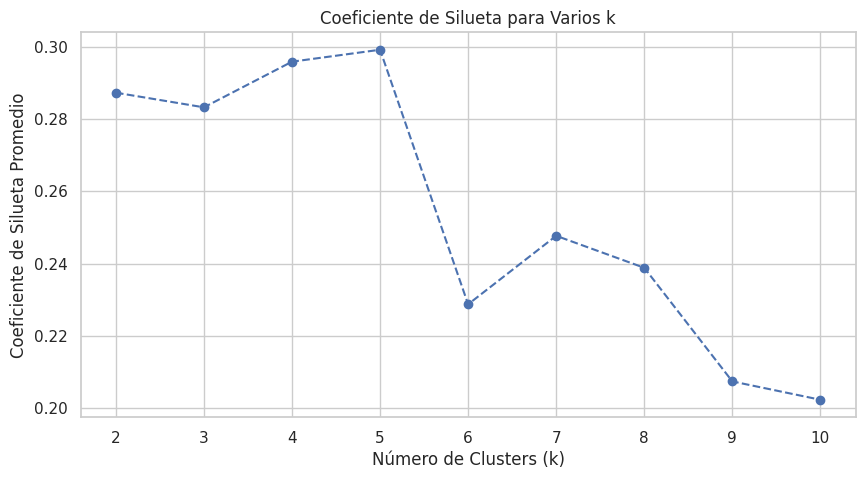

In [13]:
range_n_clusters = range(2, 11)
silhouette_avg_scores = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)
    print(f"Para n_clusters = {n_clusters}, el coeficiente de silueta promedio es: {silhouette_avg:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avg_scores, marker='o', linestyle='--')
plt.title('Coeficiente de Silueta para Varios k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.show()

4. ¿Qué número de clusters (k) parece ser el más adecuado según el coeficiente de silueta? Justifiquen su elección.

El número de clusters más adecuado es k = 5, ya que en la gráfica este valor presenta el coeficiente de silueta más alto (aproximadamente 0.2993).

Esto indica que con 5 clusters se logra la mejor combinación entre separación entre grupos y coherencia interna dentro de cada cluster

Por lo tanto, los datos están mejor agrupados cuando se utilizan 5 clusters.

5. Basados en los resultados del método del codo y el coeficiente de silueta, tomen una decisión de cuántos clusters usar. Justifiquen su elección.

El método del codo sugería que el número óptimo de clusters era k = 3, ya que a partir de ese punto la disminución de la inercia se vuelve menos pronunciada.
El coeficiente de silueta, en cambio, indica que el mejor valor es k = 5, al presentar el puntaje más alto.

Aunque el método del codo sugiere k = 3 por simplicidad, el coeficiente de silueta indica que k = 5 ofrece una mejor calidad de agrupamiento. Por lo tanto, se decide utilizar k = 5, ya que proporciona clusters más definidos y mejor separados.

6. Aplica K-Means con el k que tu grupo eligió.

In [14]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters_kmeans = kmeans.fit_predict(df_scaled)
clusters_kmeans

array([1, 0, 0, 1, 0, 0, 0, 3, 3, 0, 3, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 1,
       0, 3, 0, 1, 1, 0, 1, 3, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 3, 3,
       3, 0, 0, 0, 0, 1, 1, 0, 0, 3, 3, 1, 1, 0, 3, 1, 3, 0, 0, 1, 1, 0,
       1, 0, 3, 0, 0, 0, 1, 3, 3, 3, 0, 3, 0, 0, 1, 1, 3, 0, 1, 0, 0, 1,
       1, 0, 0, 2, 0, 1, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       3, 3, 1, 4, 3, 0, 1, 0, 0, 0, 0, 0, 3, 3, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 2, 0, 3, 1, 1, 3, 3, 0, 0, 1, 0, 3, 3, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 3, 3, 3, 0, 0, 0, 0, 0, 1, 1], dtype=int32)

7. Añade la asignación de clusters al DataFrame original

In [15]:
df['cluster_kmeans'] = clusters_kmeans

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_kmeans
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553,1
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090,0
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460,0
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530,1
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200,0


## Ejercicio 5: Análisis e Interpretación de los Clusters

Ahora que tienes los grupos, necesitas entender qué los caracteriza.

1. Calcula el promedio de cada variable para cada cluster.
Esto te dará el "perfil" de cada grupo.

In [16]:
cluster_profile = df.groupby('cluster_kmeans').mean(numeric_only=True)
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_kmeans,,,,,,,,,
0,21.61,40.98,6.17,47.52,"12,801.07",7.62,73.00,2.28,"6,581.81"
1,90.79,29.66,6.46,43.68,"3,870.70",9.95,59.21,4.97,"1,900.26"
2,4.13,176.00,6.79,156.67,"64,033.33",2.47,81.43,1.38,"57,566.67"
3,5.18,46.12,9.09,40.58,"44,021.88",2.51,80.08,1.79,"42,118.75"
4,130.00,25.30,5.07,17.40,"5,150.00",104.00,60.50,5.84,"2,330.00"


2. Visualiza los resultados. Un scatter plot de 'gdpp' vs 'child_mort' es un buen punto de partida.

Text(0.5, 1.0, 'Clusters: GDP vs Child Mortality')

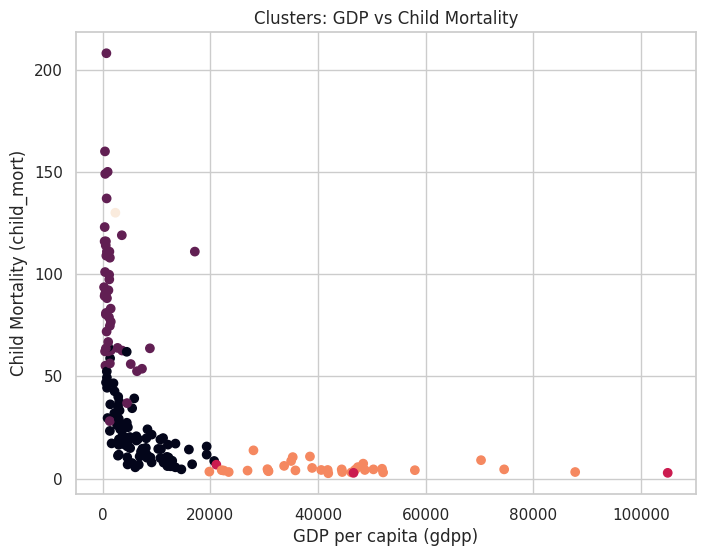

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(df['gdpp'], df['child_mort'], c=df['cluster_kmeans'])
plt.xlabel('GDP per capita (gdpp)')
plt.ylabel('Child Mortality (child_mort)')
plt.title('Clusters: GDP vs Child Mortality')

3. **Nombra los clusters:** Basado en el perfil de cada uno, dale un nombre descriptivo.


In [18]:
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_kmeans,,,,,,,,,
0,21.61,40.98,6.17,47.52,"12,801.07",7.62,73.00,2.28,"6,581.81"
1,90.79,29.66,6.46,43.68,"3,870.70",9.95,59.21,4.97,"1,900.26"
2,4.13,176.00,6.79,156.67,"64,033.33",2.47,81.43,1.38,"57,566.67"
3,5.18,46.12,9.09,40.58,"44,021.88",2.51,80.08,1.79,"42,118.75"
4,130.00,25.30,5.07,17.40,"5,150.00",104.00,60.50,5.84,"2,330.00"



*   Cluster 0: Países en vía de desarrollo.
*   Cluster 1: Países vulnerables o con economías rezagadas.
*   Cluster 2: Potencias mundiales.
*   Cluster 3: Países desarrollados.
*   Cluster 4: Países en crisis.








4. **Describe cada cluster:** Para cada grupo, describe sus características principales.



*   **Países en vía de desarrollo:** Este grupo presenta niveles intermedios de ingreso y PIB per cápita, lo que indica una posición económica moderada a nivel global. La mortalidad infantil es relativamente baja y la esperanza de vida es aceptable, lo que sugiere que cuentan con sistemas de salud funcionales, aunque no necesariamente de alta calidad. Además, las tasas de fertilidad no son extremadamente altas, lo que refleja cierta transición demográfica.
*   **Países vulnerables o con economías rezagadas:** Este cluster se caracteriza por bajos niveles de ingreso y PIB per cápita, acompañados de una alta mortalidad infantil y una elevada tasa de fertilidad. La esperanza de vida es más baja en comparación con otros grupos, lo que evidencia limitaciones en el acceso a servicios de salud, nutrición y condiciones básicas de bienestar Estos indicadores reflejan problemas estructurales como pobreza, desigualdad y acceso limitado a educación y servicios públicos.
*   **Potencias mundiales:** Este grupo presenta los niveles más altos de ingreso y PIB per cápita, junto con tasas muy bajas de mortalidad infantil y una alta esperanza de vida. Estos indicadores reflejan economías consolidadas, con sistemas de salud avanzados, alta inversión en educación y un elevado nivel de bienestar general. En estos casos, la tasa de fertilidad es baja, lo cual es típico de economías desarrolladas en etapas avanzadas de transición demográfica.
*   **Países desarrollados:** Este grupo se caracteriza por niveles relativamente altos de ingreso y PIB per cápita, aunque no tan elevados como los países que son potencias mundiales. Presenta una buena esperanza de vida y bajas tasas de mortalidad infantil, lo que indica avances significativos en salud y bienestar. Estos países suelen estar en un proceso de crecimiento sostenido, con mejoras en infraestructura, educación y desarrollo económico.
*   **Países en crisis:** Estos países presentan las condiciones más críticas entre todos los grupos, con niveles muy altos de mortalidad infantil, inflación extremadamente elevada, bajos ingresos y una alta tasa de fertilidad. La esperanza de vida es relativamente baja, lo que refleja graves limitaciones en el acceso a servicios de salud y condiciones básicas de vida.La alta inflación puede sugerir inestabilidad económica, lo que agrava aún más las condiciones de pobreza y vulnerabilidad.







5. **Recomendación de Política:** Elije un cluster y propón un tipo de programa de ayuda o política pública que el PNUD podría implementar para ellos.

**RECOMENDACIONES DE POLÍTICA Y AYUDAS PARA PAÍSES EN CRISIS (POR EL PNUD):**
Este cluster presenta las condiciones más críticas, con alta mortalidad infantil, elevada inflación, bajos niveles de ingreso y alta tasa de fertilidad, lo que evidencia una situación de vulnerabilidad estructural.

En este contexto, el PNUD podría desempeñar un papel clave mediante el apoyo técnico y financiero a estos países. En primer lugar, podría impulsar programas orientados al fortalecimiento de los sistemas de salud, especialmente en atención materno-infantil, promoviendo el acceso a servicios básicos, campañas de vacunación y estrategias de nutrición.

Asimismo, el PNUD podría colaborar con los gobiernos en el diseño e implementación de políticas de desarrollo sostenible, brindando asesoría para mejorar la gestión institucional y la eficiencia del gasto público, particularmente en sectores sociales como salud y educación.

Adicionalmente, podría promover programas de educación y empoderamiento, especialmente dirigidos a mujeres, así como facilitar el acceso a servicios de planificación familiar, contribuyendo a reducir la tasa de fertilidad y mejorar las condiciones de vida.

En el ámbito económico, el PNUD puede apoyar iniciativas de desarrollo productivo, fortalecimiento de capacidades locales e inversión en infraestructura para fomentar un crecimiento inclusivo y sostenible en el largo plazo.